In [3]:
# importing required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings('ignore')

In [4]:
# define dataset path
data_dir = 'dataset'

# class names
classes = ['normal', 'scratch', 'dent', 'stain']

# counting images in each class
class_counts = {}
for class_name in classes:
    class_path = os.path.join(data_dir, class_name)
    count = len(os.listdir(class_path))
    class_counts[class_name] = count
    print(f"{class_name}: {count} images")

# total number of images
total_images = sum(class_counts.values())
print(f"\nTotal images: {total_images}")

normal: 120 images
scratch: 120 images
dent: 120 images
stain: 120 images

Total images: 480


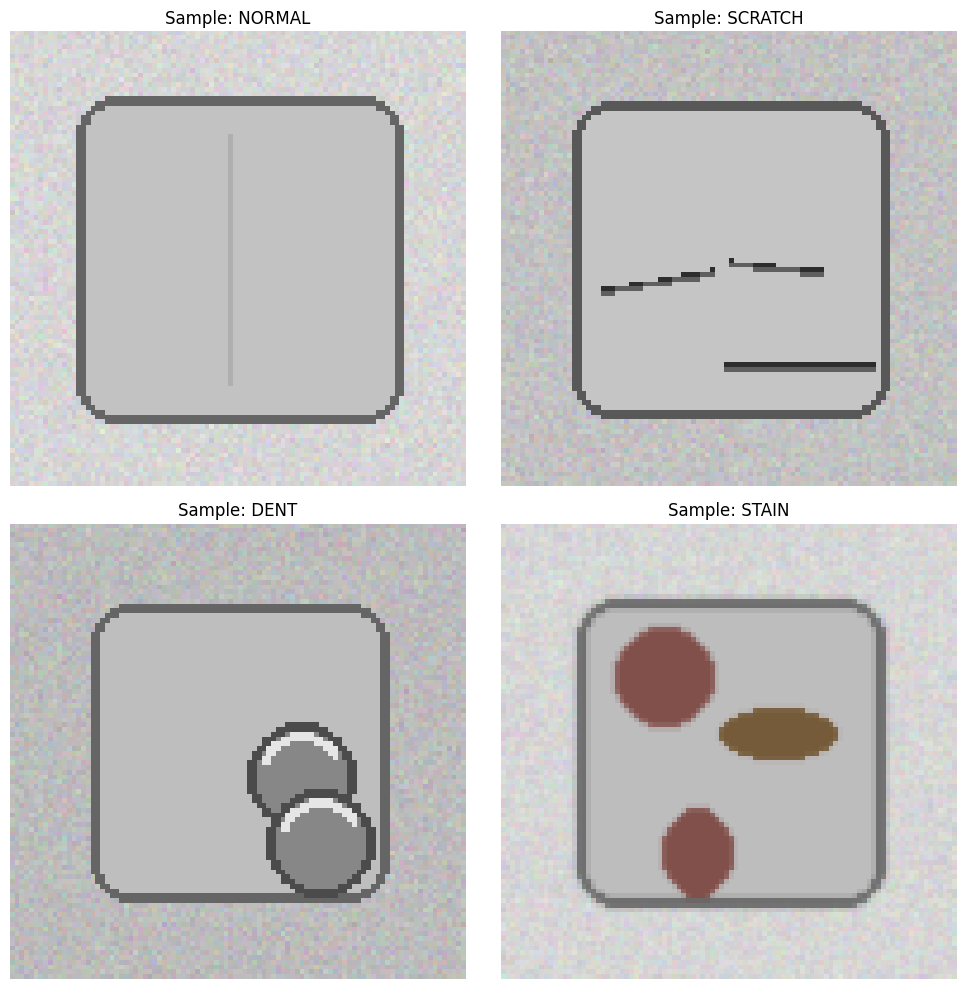

Sample image shape: (96, 96, 3)


In [5]:
# displaying sample images from each class
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for idx, class_name in enumerate(classes):
    ax = axes[idx // 2, idx % 2]
    class_path = os.path.join(data_dir, class_name)
    image_file = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_file)

    # open image
    img = Image.open(image_path)
    ax.imshow(img)
    ax.set_title(f"Sample: {class_name.upper()}")
    ax.axis('off')
plt.tight_layout()

# save output image
plt.savefig('prediction_outputs.png')
plt.show()

# image dimensions
print("Sample image shape:", np.array(img).shape)

In [6]:
# loading and resizing images
images = []
labels = []

# fixed image size
image_size = (128, 128)
for class_idx, class_name in enumerate(classes):
    class_path = os.path.join(data_dir, class_name)

    for image_file in os.listdir(class_path):
        image_path = os.path.join(class_path, image_file)

        # open image
        img = Image.open(image_path)

        # resize image
        img = img.resize(image_size)

        # convert image to array
        img = np.array(img)

        images.append(img)
        labels.append(class_idx)

# converting into numpy arrays
images = np.array(images, dtype='float32')
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Unique classes:", np.unique(labels))

Images shape: (480, 128, 128, 3)
Labels shape: (480,)
Unique classes: [0 1 2 3]


In [7]:
# normalizing pixel values
images = images / 255.0
print("Image min value:", images.min())
print("Image max value:", images.max())
print("Images normalized successfully!")

Image min value: 0.08627451
Image max value: 1.0
Images normalized successfully!


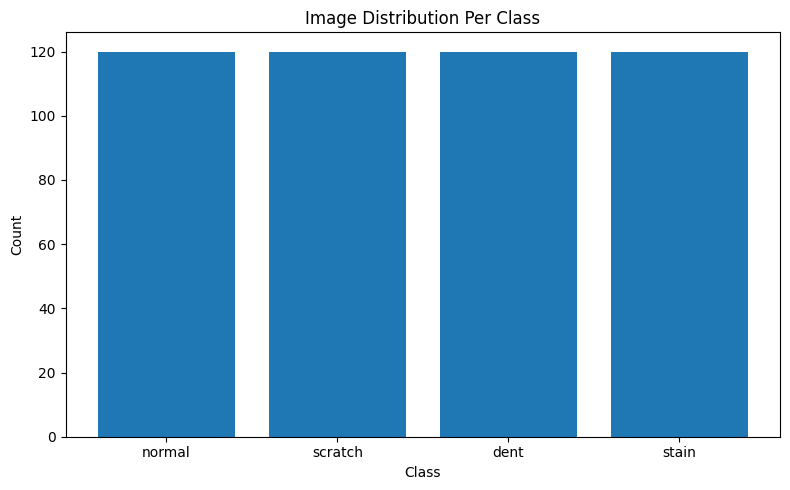

normal: 120 images
scratch: 120 images
dent: 120 images
stain: 120 images


In [8]:
# displaying class distribution
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar(classes, counts)
plt.title('Image Distribution Per Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()

# save graph
plt.savefig('class_distribution.png')
plt.show()

# print image count for each class
for class_name, count in zip(classes, counts):
    print(f"{class_name}: {count} images")

In [9]:
# splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 384
Testing set size: 96


In [10]:
# creating cnn model
model_1 = keras.Sequential([

    # first convolution layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    # second convolution layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # third convolution layer
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # flatten layer
    layers.Flatten(),

    # dense layer
    layers.Dense(128, activation='relu'),

    # output layer
    layers.Dense(4, activation='softmax')
])

# compiling the model
model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model 1 created successfully")
model_1.summary()

Model 1 created successfully


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# training the cnn model
history_1 = model_1.fit(
    X_train,
    y_train,

    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("Model 1 training completed!")

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - accuracy: 0.2117 - loss: 1.4699 - val_accuracy: 0.2857 - val_loss: 1.3854
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - accuracy: 0.2769 - loss: 1.3831 - val_accuracy: 0.3506 - val_loss: 1.3718
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step - accuracy: 0.3518 - loss: 1.3478 - val_accuracy: 0.4545 - val_loss: 1.2918
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - accuracy: 0.5309 - loss: 1.1623 - val_accuracy: 0.6234 - val_loss: 1.0025
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.6710 - loss: 0.8135 - val_accuracy: 0.4935 - val_loss: 1.0509
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.7264 - loss: 0.7203 - val_accuracy: 0.7532 - val_loss: 0.5886
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.8502 - loss: 0.4226 - val_accuracy: 0.8701 - val_loss: 0.4367
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.9055 - loss: 0.3105 - val_accuracy: 0.

In [12]:
# evaluating the cnn model
train_loss_1, train_acc_1 = model_1.evaluate(
    X_train,
    y_train,
    verbose=0
)
test_loss_1, test_acc_1 = model_1.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("=== MODEL 1 EVALUATION ===")
print(f"Training Loss: {train_loss_1:.4f}")
print(f"Training Accuracy: {train_acc_1:.4f}")
print(f"Testing Loss: {test_loss_1:.4f}")
print(f"Testing Accuracy: {test_acc_1:.4f}")

# model predictions
y_pred_1 = np.argmax(
    model_1.predict(X_test, verbose=0),
    axis=1
)

# confusion matrix
cm_1 = confusion_matrix(y_test, y_pred_1)
print("\nConfusion Matrix:")
print(cm_1)

=== MODEL 1 EVALUATION ===
Training Loss: 0.0344
Training Accuracy: 0.9870
Testing Loss: 0.4019
Testing Accuracy: 0.9062

Confusion Matrix:
[[24  0  0  0]
 [ 3 20  1  0]
 [ 0  3 20  1]
 [ 0  0  1 23]]


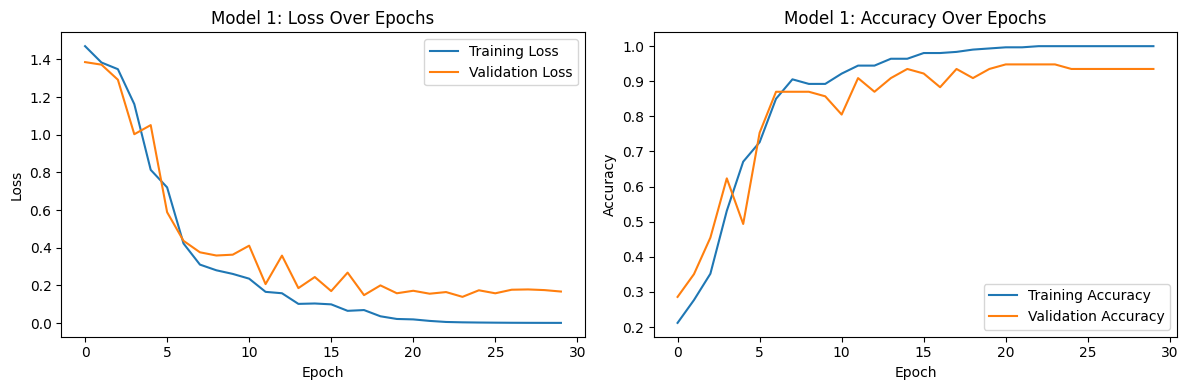

In [13]:
# plotting training and validation results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# loss graph
axes[0].plot(history_1.history['loss'], label='Training Loss')
axes[0].plot(history_1.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model 1: Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# accuracy graph
axes[1].plot(history_1.history['accuracy'], label='Training Accuracy')
axes[1].plot(history_1.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Model 1: Accuracy Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
plt.tight_layout()

# save graph
plt.savefig('accuracy_loss_curves.png')
plt.show()

In [14]:
# MODEL 2: Deeper CNN
model_2 = keras.Sequential([

    # first convolution layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    # second convolution layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # third convolution layer
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # fourth convolution layer
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # flatten layer
    layers.Flatten(),

    # dense layers
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),

    # output layer
    layers.Dense(4, activation='softmax')
])

# compile model
model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# train model
history_2 = model_2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# evaluate model
train_loss_2, train_acc_2 = model_2.evaluate(
    X_train,
    y_train,
    verbose=0
)

test_loss_2, test_acc_2 = model_2.evaluate(
    X_test,
    y_test,
    verbose=0
)

# predictions
y_pred_2 = np.argmax(
    model_2.predict(X_test, verbose=0),
    axis=1
)

print("=== MODEL 2 EVALUATION ===")
print(f"Training Accuracy: {train_acc_2:.4f}")
print(f"Testing Accuracy: {test_acc_2:.4f}")

=== MODEL 2 EVALUATION ===
Training Accuracy: 0.9974
Testing Accuracy: 1.0000


In [15]:
# MODEL 3: CNN with data augmentation

# image augmentation
data_augmentation = ImageDataGenerator(

    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,

    horizontal_flip=True,
    zoom_range=0.2
)

# creating cnn model
model_3 = keras.Sequential([

    # first convolution layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    # second convolution layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # third convolution layer
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # flatten layer
    layers.Flatten(),

    # dense layer
    layers.Dense(128, activation='relu'),

    # output layer
    layers.Dense(4, activation='softmax')
])

# compile model
model_3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# training model
history_3 = model_3.fit(

    data_augmentation.flow(X_train, y_train, batch_size=32),

    epochs=30,

    validation_data=(X_test, y_test),

    verbose=0
)

# evaluating model
train_loss_3, train_acc_3 = model_3.evaluate(
    X_train,
    y_train,
    verbose=0
)

test_loss_3, test_acc_3 = model_3.evaluate(
    X_test,
    y_test,
    verbose=0
)

# predictions
y_pred_3 = np.argmax(
    model_3.predict(X_test, verbose=0),
    axis=1
)

print("=== MODEL 3 EVALUATION ===")

print(f"Training Accuracy: {train_acc_3:.4f}")
print(f"Testing Accuracy: {test_acc_3:.4f}")

=== MODEL 3 EVALUATION ===
Training Accuracy: 0.9297
Testing Accuracy: 0.9375


In [17]:
# MODEL 4: CNN with lower learning rate

# optimizer with lower learning rate
optimizer_4 = keras.optimizers.Adam(
    learning_rate=0.0005
)

# creating cnn model
model_4 = keras.Sequential([

    # first convolution layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    # second convolution layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # third convolution layer
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # flatten layer
    layers.Flatten(),

    # dense layer
    layers.Dense(128, activation='relu'),

    # output layer
    layers.Dense(4, activation='softmax')
])

# compile model
model_4.compile(
    optimizer=optimizer_4,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# train model
history_4 = model_4.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# evaluate model
train_loss_4, train_acc_4 = model_4.evaluate(
    X_train,
    y_train,
    verbose=0
)

test_loss_4, test_acc_4 = model_4.evaluate(
    X_test,
    y_test,
    verbose=0
)

# predictions
y_pred_4 = np.argmax(
    model_4.predict(X_test, verbose=0),
    axis=1
)

print("=== MODEL 4 EVALUATION ===")

print(f"Training Accuracy: {train_acc_4:.4f}")
print(f"Testing Accuracy: {test_acc_4:.4f}")

=== MODEL 4 EVALUATION ===
Training Accuracy: 0.9818
Testing Accuracy: 0.9062


In [18]:
# comparing all models
comparison_data = {

    'Model': [
        'Model 1\n(Basic)',
        'Model 2\n(Deeper)',
        'Model 3\n(Augmentation)',
        'Model 4\n(Lower LR)'
    ],

    'Train Accuracy': [
        f'{train_acc_1:.4f}',
        f'{train_acc_2:.4f}',
        f'{train_acc_3:.4f}',
        f'{train_acc_4:.4f}'
    ],

    'Test Accuracy': [
        f'{test_acc_1:.4f}',
        f'{test_acc_2:.4f}',
        f'{test_acc_3:.4f}',
        f'{test_acc_4:.4f}'
    ],

    'Train Loss': [
        f'{train_loss_1:.4f}',
        f'{train_loss_2:.4f}',
        f'{train_loss_3:.4f}',
        f'{train_loss_4:.4f}'
    ],

    'Test Loss': [
        f'{test_loss_1:.4f}',
        f'{test_loss_2:.4f}',
        f'{test_loss_3:.4f}',
        f'{test_loss_4:.4f}'
    ]
}

# creating dataframe
comparison_df = pd.DataFrame(comparison_data)

print("\n=== MODEL COMPARISON TABLE ===")
print(comparison_df.to_string(index=False))

# save comparison table
comparison_df.to_csv('model_comparison_table.csv', index=False)


=== MODEL COMPARISON TABLE ===
                  Model Train Accuracy Test Accuracy Train Loss Test Loss
       Model 1\n(Basic)         0.9870        0.9062     0.0344    0.4019
      Model 2\n(Deeper)         0.9974        1.0000     0.0140    0.0033
Model 3\n(Augmentation)         0.9297        0.9375     0.1541    0.1475
    Model 4\n(Lower LR)         0.9818        0.9062     0.0743    0.2292


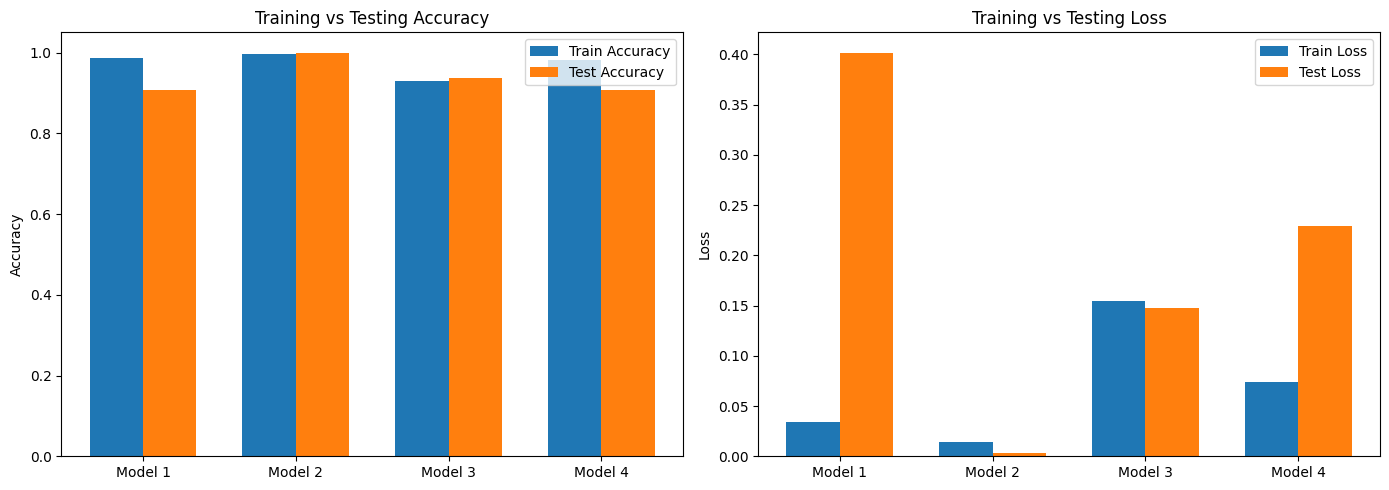

In [19]:
# comparing model performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = ['Model 1', 'Model 2', 'Model 3', 'Model 4']

train_accs = [
    train_acc_1,
    train_acc_2,
    train_acc_3,
    train_acc_4
]

test_accs = [
    test_acc_1,
    test_acc_2,
    test_acc_3,
    test_acc_4
]

x = np.arange(len(models))
width = 0.35

# accuracy comparison
axes[0].bar(x - width/2, train_accs, width, label='Train Accuracy')
axes[0].bar(x + width/2, test_accs, width, label='Test Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Testing Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()

# loss comparison
train_losses = [
    train_loss_1,
    train_loss_2,
    train_loss_3,
    train_loss_4
]

test_losses = [
    test_loss_1,
    test_loss_2,
    test_loss_3,
    test_loss_4
]

axes[1].bar(x - width/2, train_losses, width, label='Train Loss')
axes[1].bar(x + width/2, test_losses, width, label='Test Loss')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training vs Testing Loss')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].legend()
plt.tight_layout()

# save graph
plt.savefig('model_comparison.png')
plt.show()

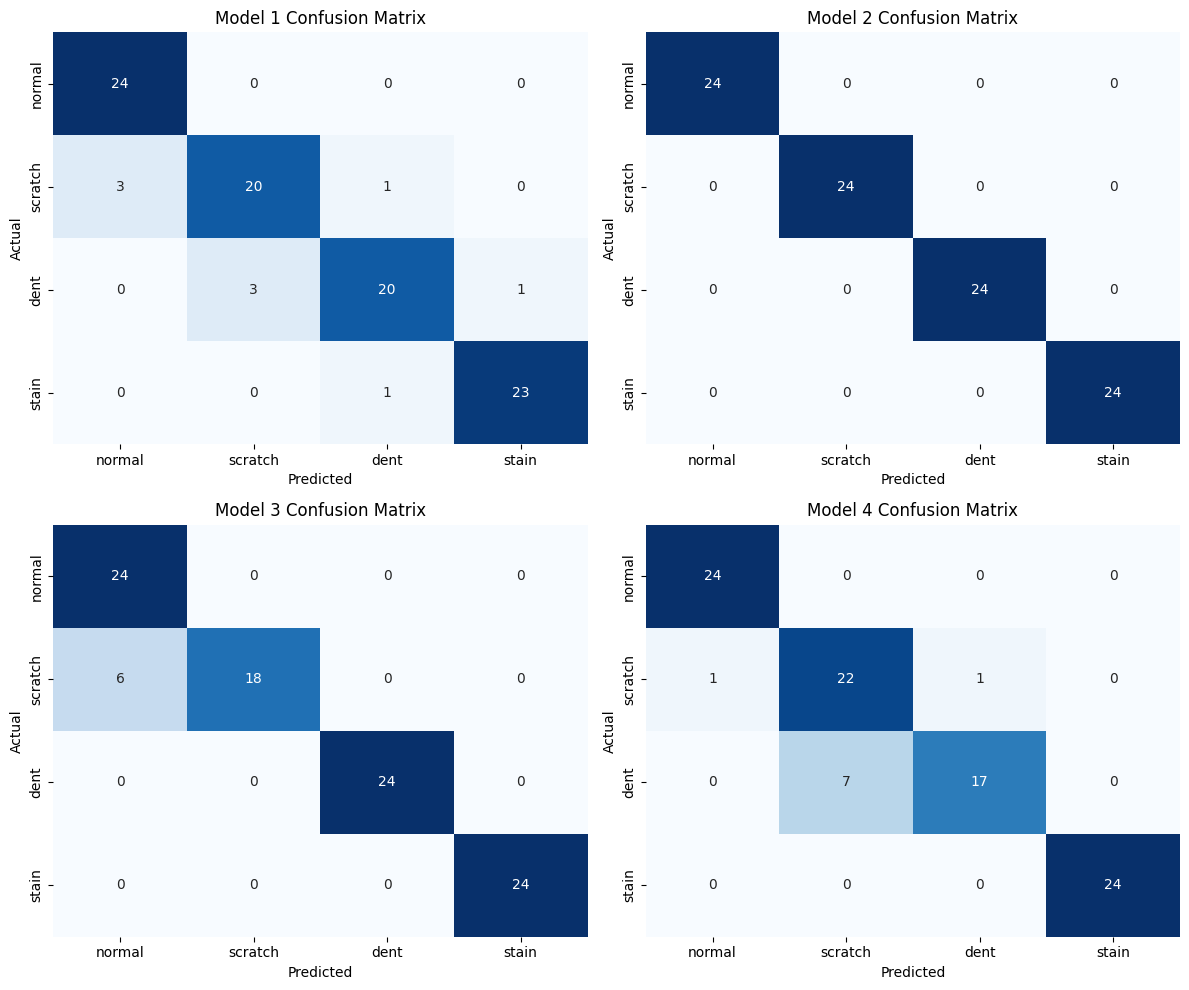

In [20]:
# confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
cms = [
    cm_1,
    confusion_matrix(y_test, y_pred_2),
    confusion_matrix(y_test, y_pred_3),
    confusion_matrix(y_test, y_pred_4)
]

model_names = [
    'Model 1',
    'Model 2',
    'Model 3',
    'Model 4'
]

for ax, cm, model_name in zip(axes.flat, cms, model_names):

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        cbar=False,
        xticklabels=classes,
        yticklabels=classes
    )

    ax.set_title(f'{model_name} Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()

# save confusion matrix image
plt.savefig('confusion_matrix.png')
plt.show()

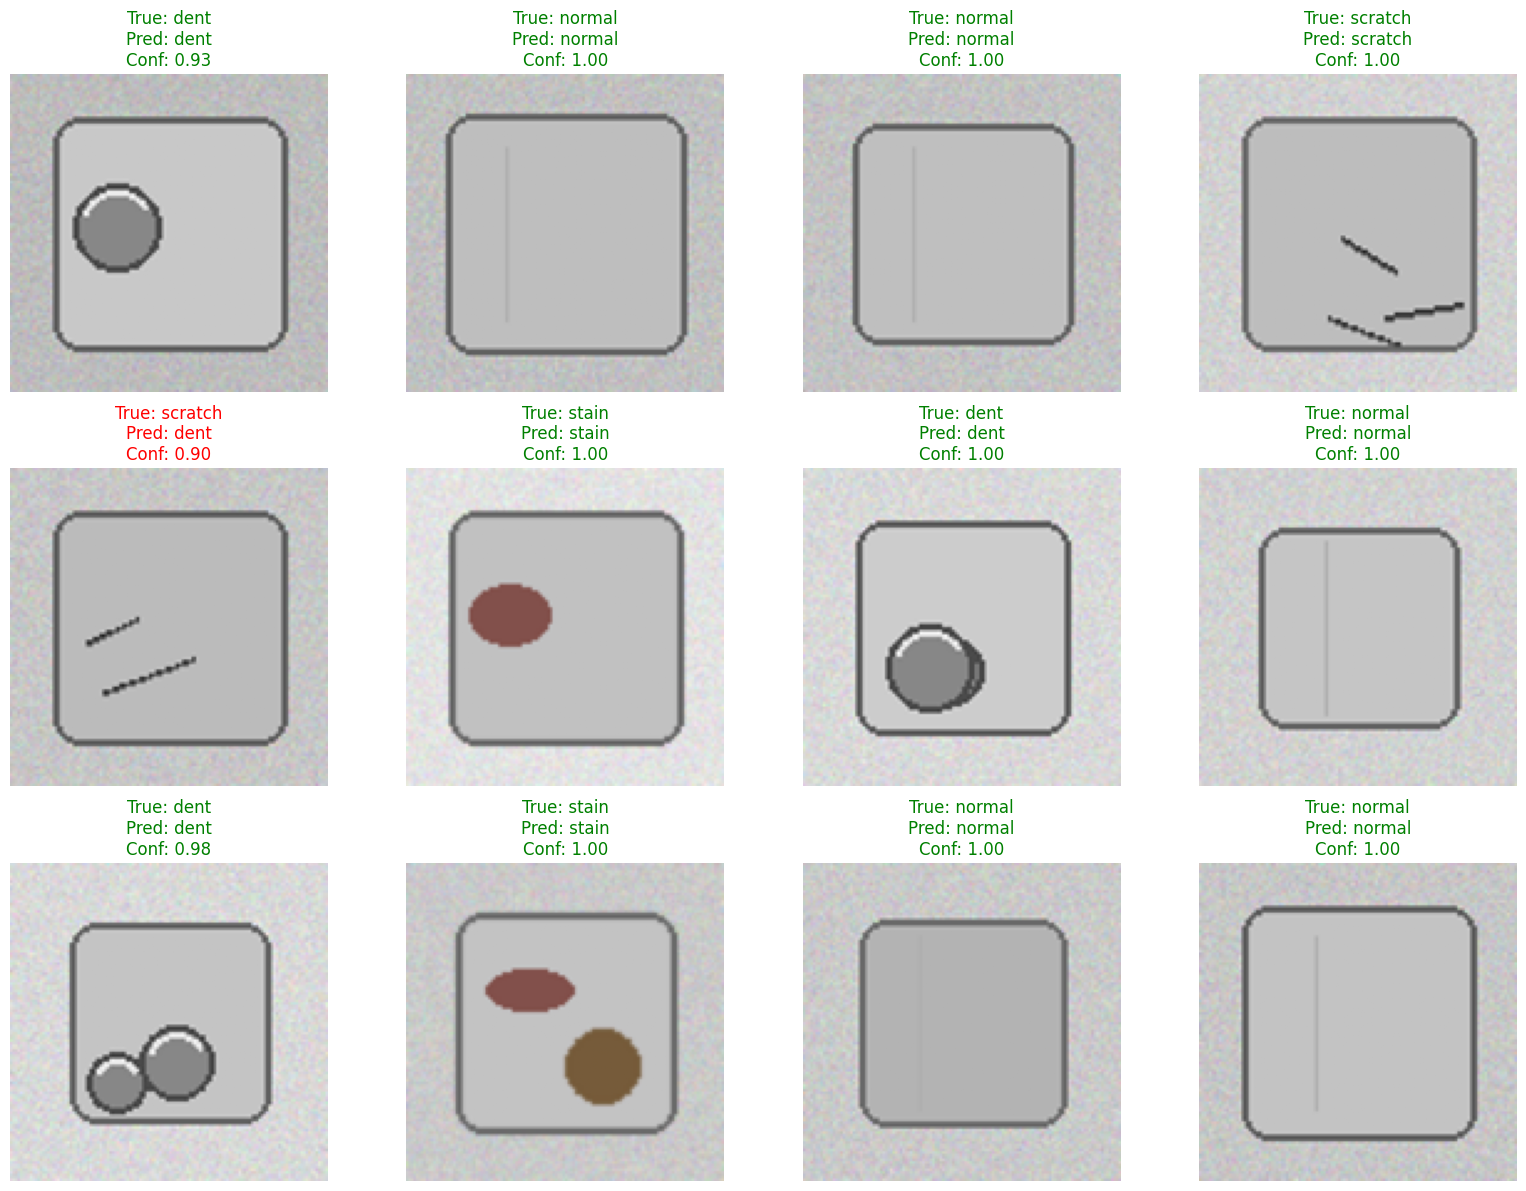

Sample predictions saved!


In [21]:
# displaying sample predictions

# using best model
best_model = model_1

# predictions
y_pred_best = best_model.predict(X_test, verbose=0)

# selecting random test images
np.random.seed(42)

indices = np.random.choice(
    X_test.shape[0],
    12,
    replace=False
)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for idx, test_idx in enumerate(indices):
    ax = axes[idx // 4, idx % 4]
    image = X_test[test_idx]
    true_label = classes[y_test[test_idx]]
    pred_label = classes[
        np.argmax(y_pred_best[test_idx])
    ]

    confidence = np.max(y_pred_best[test_idx])

    # correct or wrong prediction color
    color = 'green' if true_label == pred_label else 'red'
    ax.imshow(image)
    ax.set_title(
        f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}',
        color=color
    )

    ax.axis('off')
plt.tight_layout()

# save prediction output
plt.savefig('prediction_outputs.png')
plt.show()
print("Sample predictions saved!")

In [22]:
# classification report for model 1
print("\n=== CLASSIFICATION REPORT - MODEL 1 ===")
print(
    classification_report(
        y_test,
        y_pred_1,
        target_names=classes
    )
)


=== CLASSIFICATION REPORT - MODEL 1 ===
              precision    recall  f1-score   support

      normal       0.89      1.00      0.94        24
     scratch       0.87      0.83      0.85        24
        dent       0.91      0.83      0.87        24
       stain       0.96      0.96      0.96        24

    accuracy                           0.91        96
   macro avg       0.91      0.91      0.91        96
weighted avg       0.91      0.91      0.91        96



In [23]:
# saving the best cnn model
best_model.save('best_cnn_model.keras')
print("Best model saved successfully")

Best model saved successfully
